# EDA y regresión — Análisis nutricional y densidad calórica
**Lead University · Minería de Datos · Tarea 2**

Exploración visual, ANOVA y regresión lineal múltiple sobre el dataset `daily_food_nutrition_dataset.csv`.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

from scripts import (
    GraficosCuantitativos,
    TestEstadisticos,
    RegresionLineal,
)

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerias cargadas.')

Librerias cargadas.


In [4]:
df_raw = pd.read_csv(
    'datos/daily_food_nutrition_dataset.csv',
    on_bad_lines='skip',
    engine='python',
)

df = df_raw.rename(columns={
    'Food_Item': 'food',
    'Category': 'category',
    'Calories (kcal)': 'calories',
    'Protein (g)': 'protein',
    'Carbohydrates (g)': 'carbs',
    'Fat (g)': 'fat',
    'Fiber (g)': 'fiber',
    'Sugars (g)': 'sugar',
    'Sodium (mg)': 'sodium',
    'Cholesterol (mg)': 'cholesterol',
    'Meal_Type': 'meal_type',
    'Water_Intake (ml)': 'water',
})

print(f'Registros: {df.shape[0]} | Variables: {df.shape[1]}')
print(f'Categorias: {sorted(df["category"].unique())}')
df.head()

Registros: 645 | Variables: 12
Categorias: ['Beverage', 'Beverage/Dairy', 'Beverage/Dairy-Alt', 'Beverage/Meal', 'Condiment', 'Condiment/Dairy', 'Condiment/Processed', 'Dairy', 'Dairy/Dessert', 'Dessert', 'Fruit', 'Grain', 'Grain/Dessert', 'Grain/Processed', 'Legume', 'Meal', 'Meal/Fish', 'Meal/Fruit', 'Meal/Grain', 'Meal/Legume', 'Meal/Meat', 'Meal/Pasta', 'Meal/Processed', 'Meal/Protein', 'Meal/Rice', 'Meal/Seafood', 'Meal/Soup', 'Meal/Vegetable', 'Meal/Vegetarian', 'Nut', 'Protein', 'Protein/Dairy', 'Protein/Fish', 'Protein/Meat', 'Protein/Processed', 'Protein/Seafood', 'Protein/Vegetarian', 'Snack', 'Snack/Appetizer', 'Snack/Dessert', 'Snack/Processed', 'Supplement', 'Supplement/Processed', 'Vegetable', 'Vegetable/Condiment', 'Vegetable/Processed']


,food,category,calories,protein,carbs,fat,fiber,sugar,sodium,cholesterol,meal_type,water
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


---
## 2.1 Minería y perfilamiento

### 2.1.1 Composición por categoría — Barras apiladas de macronutrientes

Promedio de `protein`, `carbs` y `fat` para las **10 categorías** con más registros.

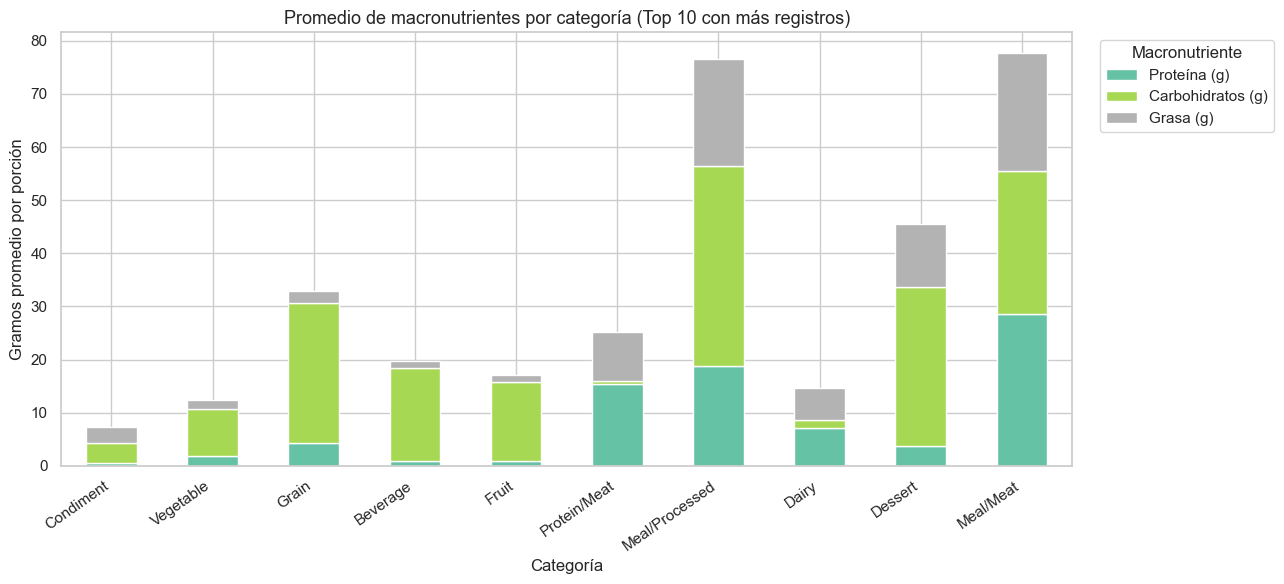

Registros por categoría (Top 10):
category
Condiment         120
Vegetable          70
Grain              59
Beverage           54
Fruit              34
Protein/Meat       31
Meal/Processed     30
Dairy              27
Dessert            27
Meal/Meat          20


In [5]:
top10 = df['category'].value_counts().head(10).index.tolist()
df_top = df[df['category'].isin(top10)]

macro_avg = (
    df_top.groupby('category')[['protein', 'carbs', 'fat']]
    .mean()
    .loc[top10]  # mantener orden por frecuencia
    .rename(columns={'protein': 'Proteína (g)', 'carbs': 'Carbohidratos (g)', 'fat': 'Grasa (g)'})
)

fig, ax = plt.subplots(figsize=(13, 6))
macro_avg.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Promedio de macronutrientes por categoría (Top 10 con más registros)', fontsize=13)
ax.set_xlabel('Categoría')
ax.set_ylabel('Gramos promedio por porción')
ax.legend(title='Macronutriente', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('Registros por categoría (Top 10):')
print(df['category'].value_counts().head(10).to_string())

**Interpretación:**

- Las categorías proteicas dominan en proteína por porción; Grains y Snacks lideran en carbohidratos.
- La grasa sobresale en categorías de aceites/grasas. Dado que 1 g grasa = 9 kcal (vs 4 kcal/g de proteína y carbs), estas concentran el mayor riesgo de exceso calórico.
- Herramienta útil para perfilamiento nutricional rápido al diseñar menús balanceados.

### 2.1.2 Relación calórica — Scatter `fat` vs `calories` con curva LOWESS

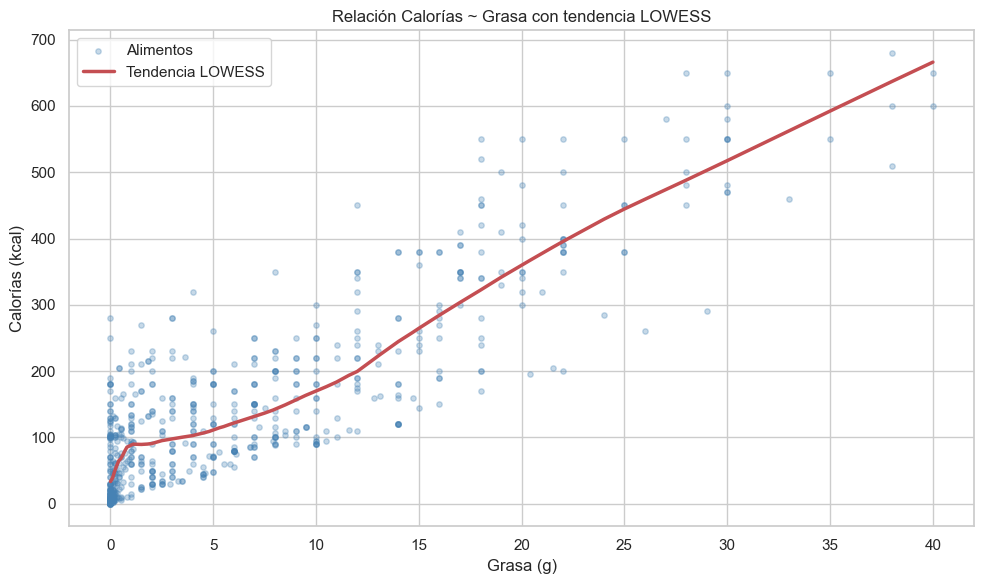

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['fat'], df['calories'], alpha=0.3, s=15, color='steelblue', label='Alimentos')

# Curva LOWESS sobre los datos ordenados
xy = df[['fat', 'calories']].dropna().sort_values('fat')
smooth = lowess(xy['calories'].values, xy['fat'].values, frac=0.3)
ax.plot(smooth[:, 0], smooth[:, 1], 'r-', lw=2.5, label='Tendencia LOWESS')

ax.set_xlabel('Grasa (g)')
ax.set_ylabel('Calorías (kcal)')
ax.set_title('Relación Calorías ~ Grasa con tendencia LOWESS')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:**

- Tendencia positiva y aproximadamente lineal: mayor grasa → mayor densidad calórica.
- La dispersión alrededor de la curva indica que alimentos con igual grasa difieren en calorías según sus otros macronutrientes.
- LOWESS captura curvatura local sin asumir linealidad global, ventaja frente a una regresión lineal simple.

---
## 2.2 ANOVA y comparaciones múltiples

### 2.2.1 ANOVA de una vía

¿Varía significativamente el contenido de `sugar` entre **Fruit** y **Grain**?

- **H₀:** La media de azúcar es igual en ambas categorías.
- **H₁:** Las medias difieren (α = 0.05).

In [7]:
df_fg = df[df['category'].isin(['Fruit', 'Grain'])].copy()

print('Registros por categoría:')
print(df_fg['category'].value_counts().to_string())
print()
print(df_fg.groupby('category')['sugar'].agg(['mean', 'median', 'std']).round(2))

Registros por categoría:
category
Grain    59
Fruit    34

           mean  median   std
category                     
Fruit     10.58     8.7  8.94
Grain      1.90     1.2  2.01


In [8]:
tests_nut = TestEstadisticos(df_fg)

print('ANOVA de una vía: sugar ~ category')
display(tests_nut.anova('sugar', 'category'))

res_f = tests_nut.anova_scipy('sugar', 'category')
print(f"F = {res_f['F']:.4f},  p-valor = {res_f['p_valor']:.6f}")
print('Decisión:', 'Rechazar H₀ — diferencia significativa' if res_f['p_valor'] < 0.05 else 'No rechazar H₀')

ANOVA de una vía: sugar ~ category


,df,sum_sq,mean_sq,F,PR(>F)
C(category),1.0,1625.373876,1625.373876,51.543083,1.845246e-10
Residual,91.0,2869.619242,31.534277,NaN,NaN


F = 51.5431,  p-valor = 0.000000
Decisión: Rechazar H₀ — diferencia significativa


### 2.2.2 Post-hoc — Distribución del azúcar por categoría

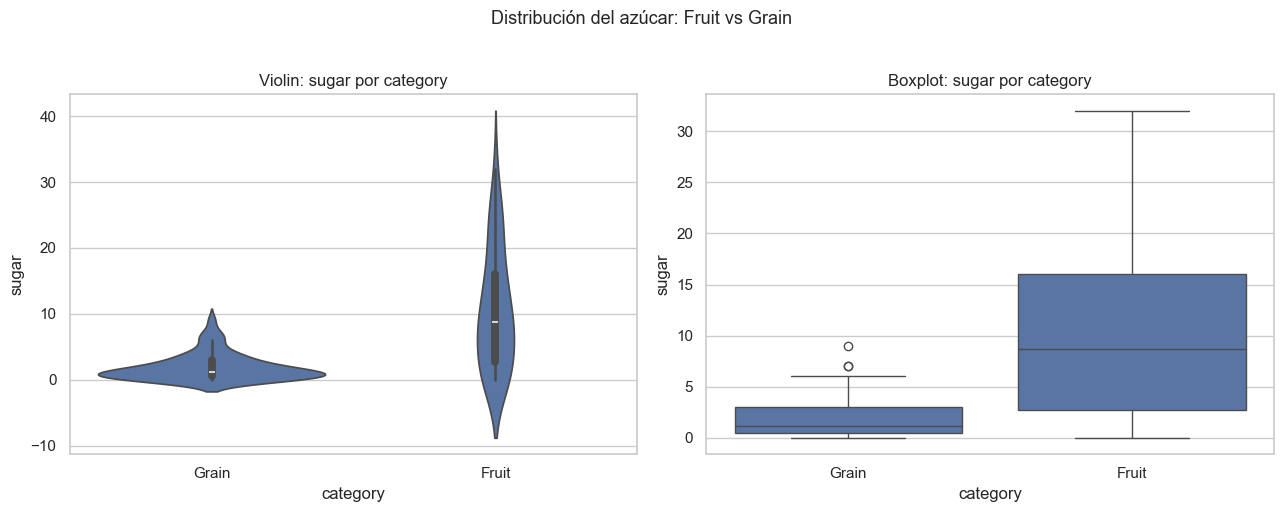

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

g_fg = GraficosCuantitativos(df_fg)
g_fg.violin(x='category', y='sugar', ax=axes[0])
g_fg.boxplot(x='category', y='sugar', ax=axes[1])

plt.suptitle('Distribución del azúcar: Fruit vs Grain', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:**

- Se rechaza H₀ (F = 51.54, p < 0.05): las frutas contienen significativamente más azúcar que los granos (media 10.6 vs 1.9 g).
- Las frutas presentan mayor variabilidad (desde aguacate/limón hasta mango/plátano); los granos son más compactos y asimétricos a la derecha.
- Diferencia relevante en nutrición clínica para planes de diabetes tipo 2 o síndrome metabólico.

---
## 2.3 Regresión lineal múltiple

**Modelo:**

$$\text{Calories} = \beta_0 + \beta_1(\text{protein}) + \beta_2(\text{carbs}) + \beta_3(\text{fat}) + \beta_4(\text{sugar}) + \varepsilon$$

In [10]:
df_reg = df[['calories', 'protein', 'carbs', 'fat', 'sugar']].dropna()
print(f'Registros para la regresión: {len(df_reg):,}')
print(df_reg.describe().round(2))

Registros para la regresión: 645
       calories  protein   carbs     fat   sugar
count    645.00   645.00  645.00  645.00  645.00
mean     146.29     6.30   15.44    6.47    5.29
std      139.98     8.78   16.35    8.14    8.54
min        0.00     0.00    0.00    0.00    0.00
25%       42.00     0.50    1.30    0.20    0.40
50%      105.00     2.70    9.20    3.00    2.00
75%      200.00     7.00   27.00   10.00    6.00
max      680.00    45.00   70.00   40.00   60.00


In [11]:
reg = RegresionLineal(
    'calories ~ protein + carbs + fat + sugar',
    df_reg,
).ajustar()

print(reg.resumen())

                            OLS Regression Results                            
Dep. Variable:               calories   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     9718.
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:32:01   Log-Likelihood:                -2772.4
No. Observations:                 645   AIC:                             5555.
Df Residuals:                     640   BIC:                             5577.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3055      1.047      2.202      0.0

In [12]:
print('Coeficientes del modelo')
display(reg.coeficientes())

print('\nBondad de ajuste')
display(reg.bondad_ajuste())

Coeficientes del modelo


,coef,error_std,t,p_valor,ic_inf,ic_sup
Intercept,2.305494,1.047062,2.201870,2.803050e-02,0.249402,4.361587
protein,4.196812,0.110864,37.855338,1.748173e-165,3.979110,4.414514
carbs,3.870106,0.058308,66.373074,3.797079e-289,3.755607,3.984605
fat,8.826907,0.121305,72.766468,0.000000e+00,8.588704,9.065110
sugar,0.132986,0.102859,1.292892,1.965151e-01,-0.068997,0.334969



Bondad de ajuste


R2                0.983803
R2_ajustado       0.983702
AIC            5554.724265
BIC            5577.070516
RMSE             17.871163
dtype: float64

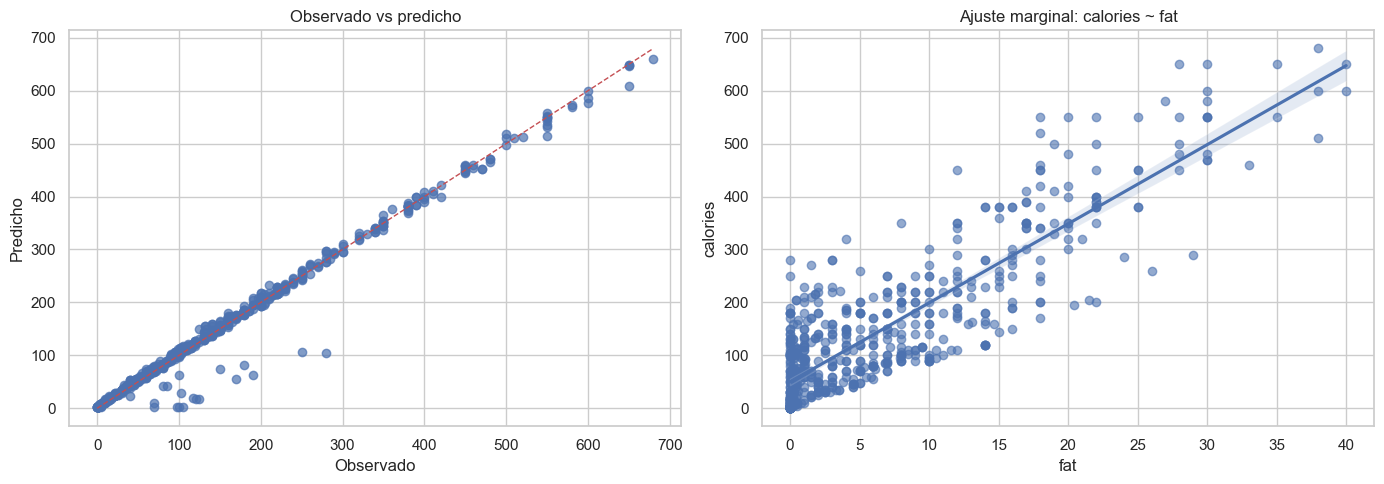

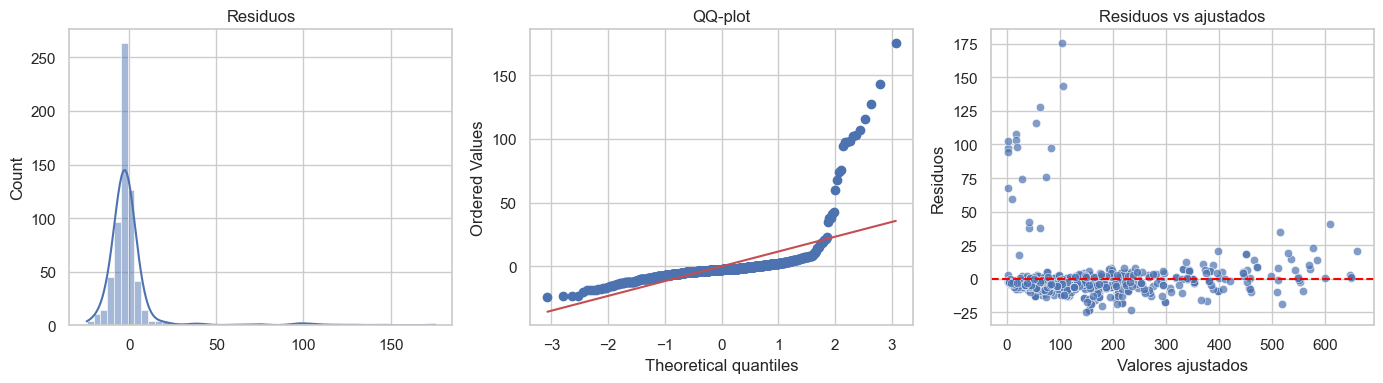

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg.grafico_predichos_vs_observados(ax=axes[0])
reg.grafico_regresion('fat', 'calories', ax=axes[1])
plt.tight_layout()
plt.show()

reg.diagnostico_residuos()
plt.show()

**Interpretación de coeficientes:**

| Predictor | Coef. | Valor Atwater | Significancia |
|-----------|-------|---------------|---------------|
| `protein` | 4.20 | 4 kcal/g | p < 0.05 |
| `carbs` | 3.87 | 4 kcal/g | p < 0.05 |
| `fat` | 8.83 | 9 kcal/g | p < 0.05 |
| `sugar` | 0.13 | (subconjunto de carbs) | p = 0.197 (no significativo) |

- Los coeficientes replican los factores de Atwater, validando el modelo.
- `sugar` no es significativo porque ya está capturado dentro de `carbs` (colinealidad parcial).

**R² ajustado = 0.984:** la composición química explica el 98.4% de la varianza en calorías. La diferencia mínima con R² indica que los predictores significativos aportan información real sin sobreajuste.

---
## Conclusiones

1. **Perfilamiento (2.1):** Las barras apiladas evidencian diferencias macronutricionales claras entre categorías; la curva LOWESS confirma la relación grasa-calorías con dispersión por otros macronutrientes.
2. **ANOVA (2.2):** Diferencia significativa en azúcar entre frutas y granos (p < 0.05), relevante en nutrición clínica.
3. **Regresión (2.3):** El modelo replica los factores de Atwater con R² = 0.984, confirmando que proteína, carbs y grasa determinan casi completamente el valor calórico.